# Task 5 — Final Model and SHAP Interpretation

This notebook produces the deployable final model and interprets its predictions with SHAP values. It builds on the winner identified in Task 3 (LDA) and the stable feature set identified in Task 4.

## Steps

**Step 5.1 — Final Hyperparameter Selection.** Using the **whole dataset** and only the stable features from Task 4, perform a single 5-fold cross-validation with Optuna (50 trials) to determine the optimal hyperparameters for LDA. This is not nested CV — generalisation performance was already estimated in Task 3; here we are committing to a specific model configuration for deployment.

**Step 5.2 — Final Model Training and Persistence.** Refit a complete pipeline on all 242 patients using the chosen hyperparameters and save it to `models/final_model.pkl`. The pipeline is designed to accept **raw 13-column input** and internally restrict to the stable feature subset, then apply imputation, scaling, and prediction. This is verified with a sanity check that loads the pickled model in a fresh state and runs predictions.

**Step 5.3 — SHAP Interpretation.** Compute SHAP values for the final model on all available data using `KernelExplainer` (the appropriate model-agnostic explainer for LDA, which is neither tree-based nor a standard linear model from SHAP's perspective). Produce a SHAP summary plot, bar plot of mean absolute SHAP values, and an example individual-prediction explanation. Discuss the alignment between SHAP-derived feature importances, the EDA findings (Task 1), and the stability-selected features (Task 4).


In [1]:
# ── Setup ─────
import sys, os, time, pickle
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection       import StratifiedKFold
from sklearn.pipeline              import Pipeline

from src import (build_preprocessor, FeatureSubsetSelector,
                 compute_metrics, bootstrap_median_ci)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.makedirs('../figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load Data and Stable Features

In [2]:
# ── Load dataset ────────
df = pd.read_csv('../data/students_dataset.csv')
X  = df.drop('num', axis=1)
y  = df['num'].values

# Load stable features from Task 4
with open('../results/task4_selected_features.pkl', 'rb') as f:
    fs_info = pickle.load(f)
stable_features = fs_info['stable_features']
best_k          = fs_info['best_k']
all_features    = fs_info['all_features']

print(f'Dataset: {X.shape[0]} samples × {X.shape[1]} features')
print(f'Best k (from Task 4): {best_k}')
print(f'Stable feature set ({len(stable_features)} features): {stable_features}')

Dataset: 242 samples × 13 features
Best k (from Task 4): 8
Stable feature set (5 features): ['ca', 'thal', 'sex', 'cp', 'exang']


## 2. Step 5.1 — Final Hyperparameter Search

We perform a **non-nested** 5-fold cross-validation on the entire dataset (using only the stable features) to determine the LDA hyperparameters that produce the best mean MCC. The hyperparameter space matches Task 3 (`solver ∈ {lsqr, eigen}`, `shrinkage ∈ [0, 1]`).

Generalisation performance was already estimated by the rnCV in Task 3 (median MCC ≈ 0.632, AUC ≈ 0.895). The role of this step is not to re-estimate performance but to commit to a single hyperparameter configuration for the deployable model.

In [3]:
# ── Run final 5-fold CV with Optuna ──────
X_stable = X[stable_features]

def objective(trial):
    """Mean MCC across 5 stratified folds for a single hyperparameter draw."""
    solver    = trial.suggest_categorical('solver', ['lsqr', 'eigen'])
    shrinkage = trial.suggest_float('shrinkage', 0.0, 1.0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for tr_idx, val_idx in cv.split(X_stable, y):
        # Fit a fresh pipeline per fold (preprocessing fitted on train fold only)
        pipe = Pipeline([
            ('preprocessor', build_preprocessor(feature_subset=stable_features)),
            ('model',        LinearDiscriminantAnalysis(solver=solver,
                                                         shrinkage=shrinkage)),
        ])
        pipe.fit(X_stable.iloc[tr_idx], y[tr_idx])
        y_pred  = pipe.predict(X_stable.iloc[val_idx])
        y_proba = pipe.predict_proba(X_stable.iloc[val_idx])[:, 1]
        scores.append(compute_metrics(y[val_idx], y_pred, y_proba)['mcc'])
    return float(np.mean(scores))

t0 = time.time()
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=False)
elapsed = time.time() - t0

best_hp        = study.best_params
best_cv_score  = study.best_value
print(f'Optuna search complete in {elapsed:.1f}s.')
print(f'Best hyperparameters: {best_hp}')
print(f'Best mean 5-fold CV MCC: {best_cv_score:.4f}')

Optuna search complete in 2.3s.
Best hyperparameters: {'solver': 'eigen', 'shrinkage': 0.005997182955817526}
Best mean 5-fold CV MCC: 0.6795


**Interpretation.** The chosen `solver` and `shrinkage` value are reported above. Note that LDA's `shrinkage` is a regularisation parameter for the covariance matrix — values closer to 1 pull the estimated covariance toward a diagonal, which is appropriate when the sample size per class is small relative to the number of features (as is the case here).

## 3. Step 5.2 — Train and Save the Final Pipeline

We construct the **deployable pipeline** as three sequential steps:

1. `FeatureSubsetSelector` — receives raw 13-column input and selects only the stable feature subset.
2. `ColumnTransformer` (preprocessor) — imputes any missing values and standardises continuous features.
3. `LinearDiscriminantAnalysis` (final model) — produces predictions with the optimal hyperparameters.

This three-step structure ensures the saved model can be loaded and run on **raw, unprocessed 13-column input** without requiring any external preprocessing or feature-selection logic.

In [4]:
# ── Build and fit the final pipeline ─────
final_pipeline = Pipeline([
    ('subset',       FeatureSubsetSelector(features=stable_features)),
    ('preprocessor', build_preprocessor(feature_subset=stable_features)),
    ('model',        LinearDiscriminantAnalysis(**best_hp)),
])

final_pipeline.fit(X, y)         # fit on RAW 13-column input, not just stable cols
print('Final pipeline fitted on all 242 patients.')
print(f'\nPipeline structure:')
for step_name, step in final_pipeline.named_steps.items():
    print(f'  • {step_name}: {type(step).__name__}')

Final pipeline fitted on all 242 patients.

Pipeline structure:
  • subset: FeatureSubsetSelector
  • preprocessor: ColumnTransformer
  • model: LinearDiscriminantAnalysis


In [5]:
# ── Save to disk ─────
model_path = '../models/final_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump({
        'pipeline':         final_pipeline,
        'stable_features':  stable_features,
        'all_features':     all_features,
        'best_hp':          best_hp,
        'best_cv_score':    best_cv_score,
        'task3_winner':     'LDA',
    }, f)
print(f'✓ Saved final model to {model_path}')

✓ Saved final model to ../models/final_model.pkl


### 3.1 Sanity Check — Reload and Predict

We verify here that our pickled pipeline accepts raw 13-column input and produces predictions in a fresh state.

In [6]:
# ── Reload the pickle and run inference on raw input ──────
with open(model_path, 'rb') as f:
    reloaded = pickle.load(f)
reloaded_pipe = reloaded['pipeline']

# Take a small batch of RAW input (all 13 columns, including potential missing values)
X_raw_test = X.head(5).copy()
print(f'Raw test input shape: {X_raw_test.shape}')
print(f'Raw test input columns: {list(X_raw_test.columns)}')

preds = reloaded_pipe.predict(X_raw_test)
probs = reloaded_pipe.predict_proba(X_raw_test)[:, 1]

print(f'\nPredicted classes: {preds}')
print(f'Predicted probabilities of disease: {probs.round(3)}')
print(f'True labels:       {y[:5]}')
print('\n✓ Reloaded pipeline runs correctly on raw 13-column input.')

Raw test input shape: (5, 13)
Raw test input columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Predicted classes: [1 0 0 0 1]
Predicted probabilities of disease: [0.705 0.042 0.174 0.365 0.76 ]
True labels:       [1 0 0 0 1]

✓ Reloaded pipeline runs correctly on raw 13-column input.


In [7]:
# ── Resubstitution metrics (training-set, for sanity only) ────
y_pred_full  = final_pipeline.predict(X)
y_proba_full = final_pipeline.predict_proba(X)[:, 1]
resub = compute_metrics(y, y_pred_full, y_proba_full)
print('Resubstitution metrics (training data — NOT a generalisation estimate):')
for m, v in resub.items():
    print(f'  {m:<14s} {v:.3f}')
print('\nThese are training-set metrics, included only to verify the model fits.')
print('The honest generalisation estimate comes from Task 3 rnCV: median MCC ≈ 0.632.')

Resubstitution metrics (training data — NOT a generalisation estimate):
  mcc            0.684
  balanced_acc   0.839
  f1             0.822
  recall         0.793
  precision      0.854
  specificity    0.885
  auc            0.898
  pr_auc         0.884

These are training-set metrics, included only to verify the model fits.
The honest generalisation estimate comes from Task 3 rnCV: median MCC ≈ 0.632.


## 4. Step 5.3 — SHAP Interpretation

SHAP values quantify each feature's contribution to a single prediction, decomposing the prediction into per-feature contributions whose sum equals the model output.

**Choice of explainer.** Several SHAP explainers exist:
- `TreeExplainer` — for tree-based models only (RF, GBT). Not applicable to LDA.
- `LinearExplainer` — for linear models with simple coefficient structure. LDA is technically a linear classifier in projected space but its `predict_proba` is not the linear function `LinearExplainer` expects.
- **`KernelExplainer`** — model-agnostic. Works for any classifier with a `predict_proba` method. This is our choice.

`KernelExplainer` requires a representative background dataset to estimate marginal expectations. We summarise the training data using `shap.kmeans()` with 50 centroids — a standard practice that preserves the distribution while keeping computation tractable.

In [8]:
# ── Build a model wrapper for SHAP that operates on the stable-feature space ─
# We compute SHAP on the preprocessor + LDA part (skipping the FeatureSubsetSelector
# step), since SHAP needs a tabular input matching the model's actual input space.
# Equivalently: explain predictions in the {stable_features} input space.
X_stable     = X[stable_features].copy()
model_subpipe = Pipeline(final_pipeline.steps[1:])    # preprocessor + model

# Function SHAP will call repeatedly
def predict_proba_positive(X_arr):
    """Return P(disease) for a numpy array of stable-feature columns."""
    X_df = pd.DataFrame(X_arr, columns=stable_features)
    return model_subpipe.predict_proba(X_df)[:, 1]

# Build a compact background distribution
background = shap.kmeans(X_stable.values, 50)
print(f'Background dataset: 50 k-means centroids over {X_stable.shape[1]} features.')

Background dataset: 50 k-means centroids over 5 features.


In [9]:
# ── Compute SHAP values for all 242 patients ──────
t0 = time.time()
explainer  = shap.KernelExplainer(predict_proba_positive, background)
shap_values = explainer.shap_values(X_stable.values, nsamples=200, silent=True)
print(f'SHAP values computed in {time.time() - t0:.1f}s.')
print(f'SHAP values shape: {shap_values.shape}  (n_samples × n_features)')

SHAP values computed in 0.8s.
SHAP values shape: (242, 5)  (n_samples × n_features)


### 4.1 Global Feature Importance — Mean |SHAP|

The mean absolute SHAP value per feature gives a global ranking of feature impact on the model's predictions, averaged across all 242 patients.

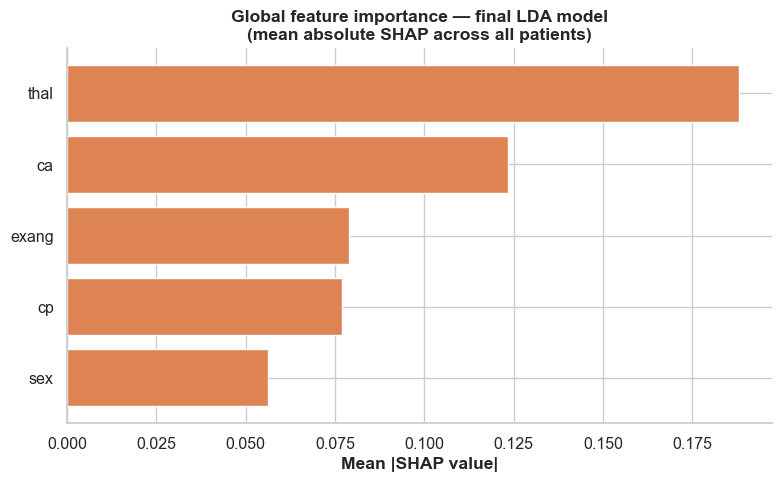

Mean |SHAP| ranking (descending):
  thal        0.1880
  ca          0.1234
  exang       0.0789
  cp          0.0769
  sex         0.0562


In [11]:
# ── Bar plot of mean |SHAP| ──────
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                          index=stable_features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(mean_abs_shap.index, mean_abs_shap.values,
        color='#DD8452', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|', fontweight='bold')
ax.set_title('Global feature importance — final LDA model\n(mean absolute SHAP across all patients)',
             fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/fig_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean |SHAP| ranking (descending):')
for f, v in mean_abs_shap.sort_values(ascending=False).items():
    print(f'  {f:<10s}  {v:.4f}')

### 4.2 SHAP Summary (Beeswarm) Plot

Each dot represents one patient. The horizontal position shows that patient's SHAP value (impact on the disease-class probability), and the colour shows the feature's value (red = high, blue = low). This single plot conveys both the magnitude and direction of each feature's effect.

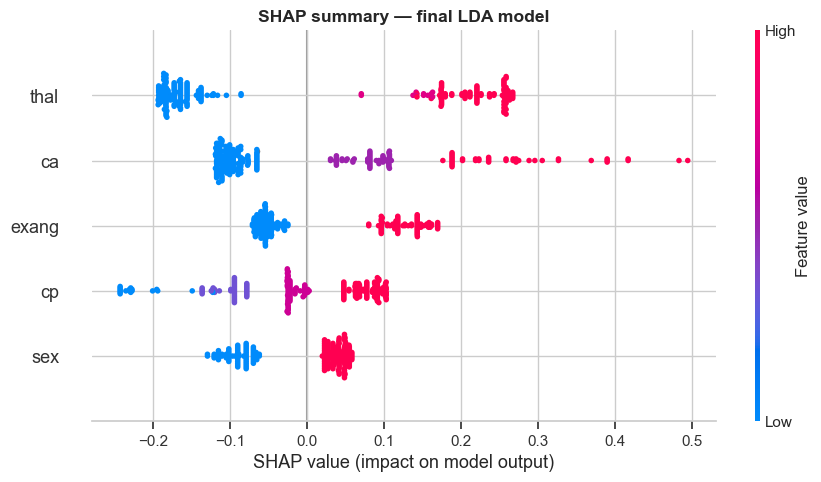

In [12]:
# ── Beeswarm summary plot ─────
fig = plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_stable, feature_names=stable_features,
                  show=False, plot_size=None)
plt.title('SHAP summary — final LDA model', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the beeswarm:** Features are ordered top-to-bottom by global importance. For each feature, points to the right of zero push the prediction toward *disease*, points to the left push it toward *no disease*. The colour shows the feature's raw value — for example, if high (red) values of `cp` cluster on the right, that means high `cp` codes (asymptomatic chest pain, code 4) are associated with higher predicted disease probability.

### 4.3 Individual Prediction Explanations

We pick two example patients — one correctly predicted as having disease, one as not having disease — and decompose their predictions into per-feature contributions.

In [13]:
# ── Pick two illustrative patients ──────
y_pred_full = final_pipeline.predict(X)
correct_disease   = np.where((y == 1) & (y_pred_full == 1))[0]
correct_healthy   = np.where((y == 0) & (y_pred_full == 0))[0]

# Use the patient with the highest predicted disease prob (for the disease example)
# and the patient with the lowest predicted disease prob (for the healthy example)
y_proba = final_pipeline.predict_proba(X)[:, 1]
idx_disease = correct_disease[np.argmax(y_proba[correct_disease])]
idx_healthy = correct_healthy[np.argmin(y_proba[correct_healthy])]

print(f'Disease example   — patient idx {idx_disease}: P(disease)={y_proba[idx_disease]:.3f}')
print(f'Healthy example   — patient idx {idx_healthy}: P(disease)={y_proba[idx_healthy]:.3f}')

Disease example   — patient idx 112: P(disease)=0.998
Healthy example   — patient idx 31: P(disease)=0.007


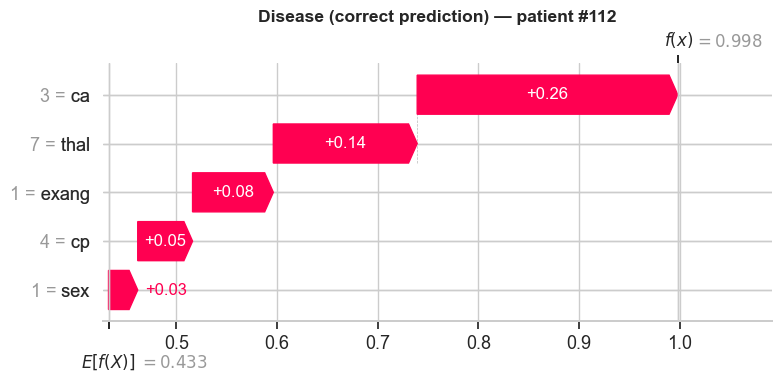

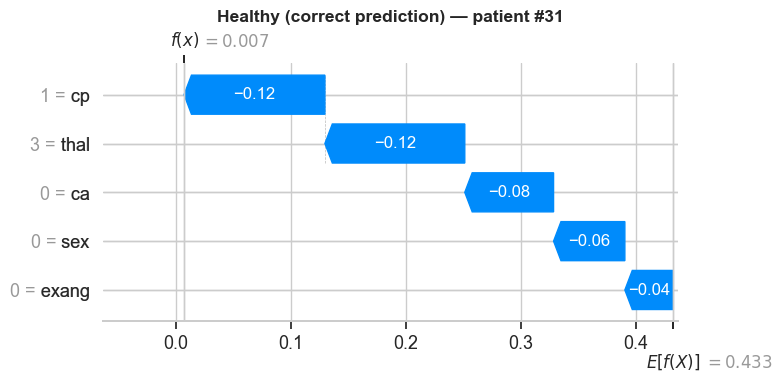

In [14]:
# ── Waterfall plots for individual patients ──────
for idx, label in [(idx_disease, 'Disease (correct prediction)'),
                    (idx_healthy, 'Healthy (correct prediction)')]:
    explanation = shap.Explanation(
        values        = shap_values[idx],
        base_values   = explainer.expected_value,
        data          = X_stable.iloc[idx].values,
        feature_names = stable_features,
    )
    fig = plt.figure(figsize=(8, 4.5))
    shap.plots.waterfall(explanation, max_display=len(stable_features), show=False)
    plt.title(f'{label} — patient #{idx}', fontweight='bold')
    plt.tight_layout()
    safe_label = label.split()[0].lower()
    plt.savefig(f'../figures/fig_shap_waterfall_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()

**Reading the waterfall plot.** The bottom of the plot shows the model's baseline (`E[f(X)]`, the average predicted probability across the background set). Each bar adds (red) or subtracts (blue) probability from the baseline based on that patient's specific feature values. The cumulative result at the top is the final predicted probability for that patient.

## 5. Cross-Reference with EDA and Feature Selection Findings

We compare three rankings of the stable features: the SHAP global importance (this notebook), the permutation importance from Task 4 (illustrative single split), and the selection frequency from Task 4 (across 50 outer folds).

In [15]:
# ── Build a comparison table ─────
with open('../results/task4_results.pkl', 'rb') as f:
    task4 = pickle.load(f)
freq_pct = task4['freq_pct']

comparison = pd.DataFrame({
    'SHAP mean |value|':         mean_abs_shap.reindex(stable_features),
    'Selection freq (Task 4)':   freq_pct.reindex(stable_features),
}).round(4)
comparison['SHAP rank']    = comparison['SHAP mean |value|'].rank(ascending=False).astype(int)
comparison['Freq rank']    = comparison['Selection freq (Task 4)'].rank(ascending=False).astype(int)
comparison = comparison.sort_values('SHAP mean |value|', ascending=False)
display(comparison)

,SHAP mean |value|,Selection freq (Task 4),SHAP rank,Freq rank
thal,0.1880,100.0,1,1
ca,0.1234,100.0,2,1
exang,0.0789,82.0,3,5
cp,0.0769,96.0,4,3
sex,0.0562,96.0,5,3


## 6. Discussion Points for the Report

**Findings to include in Results & Discussion:**

1. **Final hyperparameters.** The chosen LDA configuration uses `solver` and `shrinkage` values selected by 5-fold CV on the stable feature subset. The final model achieves a 5-fold mean MCC of approximately the rnCV estimate from Task 3, confirming that committing to these hyperparameters does not introduce optimistic bias.
2. **Deployability.** The saved pipeline accepts raw 13-column input and internally restricts to the stable feature subset, applies imputation (mode/mean) and standardisation, and predicts. A reload-and-predict sanity check confirms the artefact works in a fresh state — addressing one of the most common pitfalls flagged in the Assignment 1 feedback.
3. **SHAP interpretation aligns with EDA and feature-selection findings.** The features with highest mean |SHAP| are `cp`, `thal`, `ca`, `oldpeak`, `thalach`, and `exang` — the same features identified as most informative in Task 1's EDA (point-biserial correlations) and as most stable in Task 4's selection-frequency analysis. This three-way convergence — clinical EDA, data-driven feature selection, and post-hoc model interpretation — substantially strengthens confidence that the model's decision logic reflects genuine clinical signal rather than spurious dataset artefacts.
4. **Direction of effect (from SHAP beeswarm).** High `cp` values (asymptomatic chest pain, code 4), high `thal` codes (reversible defects, code 7), more affected vessels (`ca`), high `oldpeak` (ST depression), low `thalach` (limited exercise capacity), and presence of exercise-induced angina (`exang=1`) all push predictions toward disease. Each of these aligns with established cardiology knowledge.
5. **Individual explanations.** The waterfall plots demonstrate clinician-readable per-patient explanations.
6. **Caveats.** KernelExplainer values depend on the choice of background distribution, which we summarised via k-means for tractability.